In [598]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/df_model.csv', sep=';', dtype={'CODE_INSEE': str})

display(df)

/tmp/ipykernel_4807/3470861440.py:6: DtypeWarning: Columns (0: Code_INSEE) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/df_model.csv', sep=';', dtype={'CODE_INSEE': str})


,Année,Code_INSEE,Libellé de la commune,Inscrits,Abstentions,% Abs/Ins,Votants,% Vot/Ins,Blancs,% Blancs/Ins,...,pct_55-64 ans,pct_65-79 ans,pct_80 ans et +,pct_Mariés,pct_Pacsés,pct_Concubinage,pct_Veufs,pct_Divorcés,pct_Célibataires,Population_active
0,2022,01001,L'Abergement-Clémenciat,645,108,16.74,537,83.26,16,2.48,...,18.794835,18.364419,6.312769,51.219512,7.890961,16.499283,5.882353,3.156385,15.351506,697.000000
1,2022,01002,L'Abergement-de-Varey,213,38,17.84,175,82.16,3,1.41,...,12.037037,14.814815,8.333333,47.685185,11.111111,9.722222,3.240741,7.407407,20.833333,216.000000
2,2022,01004,Ambérieu-en-Bugey,8765,2078,23.71,6687,76.29,88,1.00,...,14.436934,16.198957,6.106620,40.957640,5.835323,9.955739,6.778822,8.566899,27.644693,12594.508695
3,2022,01005,Ambérieux-en-Dombes,1282,234,18.25,1048,81.75,14,1.09,...,17.295346,15.384787,5.562916,48.809515,7.840915,14.193995,4.623646,4.509098,20.022831,1554.355560
4,2022,01006,Ambléon,103,23,22.33,80,77.67,3,2.91,...,23.076923,25.000000,5.769231,49.038462,8.653846,10.576923,2.884615,9.615385,19.230769,104.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34723,2022,95676,Villers-en-Arthies,390,50,12.82,340,87.18,2,0.51,...,16.530655,16.979097,4.528522,47.392614,4.639004,15.669851,5.102841,6.176331,21.019359,384.624042
34724,2022,95678,Villiers-Adam,603,72,11.94,531,88.06,9,1.49,...,17.428571,13.714286,7.142857,45.714286,10.142857,12.857143,5.000000,4.571429,21.714286,700.000000
34725,2022,95680,Villiers-le-Bel,12401,4013,32.36,8388,67.64,106,0.85,...,13.628300,10.714654,3.277626,44.969973,1.178277,7.481139,4.148062,5.286505,36.832896,21596.176049
34726,2022,95682,Villiers-le-Sec,110,14,12.73,96,87.27,0,0.00,...,9.027778,7.638889,6.250000,45.138889,6.944444,15.972222,4.166666,3.472222,22.222223,150.857143


In [599]:
df.dtypes

Année                            int64
Code_INSEE                      object
Libellé de la commune              str
Inscrits                         int64
Abstentions                      int64
% Abs/Ins                      float64
Votants                          int64
% Vot/Ins                      float64
Blancs                           int64
% Blancs/Ins                   float64
% Blancs/Vot                   float64
Nuls                             int64
% Nuls/Ins                     float64
% Nuls/Vot                     float64
Exprimés                         int64
% Exp/Ins                      float64
% Exp/Vot                      float64
% gauche/Exp                   float64
% centre/Exp                   float64
% droite/Exp                   float64
Résultat                           str
pct_Femmes                     float64
pct_Hommes                     float64
pct_Agriculteurs               float64
pct_Artisans                   float64
pct_Cadres               

In [600]:
df.columns

Index(['Année', 'Code_INSEE', 'Libellé de la commune', 'Inscrits',
       'Abstentions', '% Abs/Ins', 'Votants', '% Vot/Ins', 'Blancs',
       '% Blancs/Ins', '% Blancs/Vot', 'Nuls', '% Nuls/Ins', '% Nuls/Vot',
       'Exprimés', '% Exp/Ins', '% Exp/Vot', '% gauche/Exp', '% centre/Exp',
       '% droite/Exp', 'Résultat', 'pct_Femmes', 'pct_Hommes',
       'pct_Agriculteurs', 'pct_Artisans', 'pct_Cadres', 'pct_Intermédiaires',
       'pct_Employés', 'pct_Ouvriers', 'pct_Retraités', 'pct_Etudiants',
       'pct_Inactifs', 'pct_Personne seule', 'pct_Homme seul',
       'pct_Femme seule', 'pct_Colocation', 'pct_Famille',
       'pct_Famille monoparentale', 'pct_Couple sans enfant',
       'pct_Couple avec enfants', 'pct_Population avec enfants',
       'pct_15-24 ans', 'pct_25-39 ans', 'pct_40-54 ans', 'pct_55-64 ans',
       'pct_65-79 ans', 'pct_80 ans et +', 'pct_Mariés', 'pct_Pacsés',
       'pct_Concubinage', 'pct_Veufs', 'pct_Divorcés', 'pct_Célibataires',
       'Population_active']

In [601]:
print(df[df['% gauche/Exp'].isna()][['% gauche/Exp', '% centre/Exp', '% droite/Exp']])
df= df.dropna(subset=['% gauche/Exp'])

       % gauche/Exp  % centre/Exp  % droite/Exp
465             NaN           NaN           NaN
479             NaN           NaN           NaN
6584            NaN           NaN           NaN
8322            NaN           NaN           NaN
14165           NaN           NaN           NaN
15719           NaN           NaN           NaN
22687           NaN           NaN           NaN
22760           NaN           NaN           NaN
22867           NaN           NaN           NaN
23918           NaN           NaN           NaN
24286           NaN           NaN           NaN
30871           NaN           NaN           NaN
33321           NaN           NaN           NaN


In [602]:
df['majorite'] = df[['% gauche/Exp', '% centre/Exp', '% droite/Exp']].idxmax(axis=1)
metier = ['pct_Agriculteurs', 'pct_Artisans', 'pct_Cadres', 'pct_Intermédiaires', 'pct_Employés', 'pct_Ouvriers', 'pct_Retraités', 'pct_Etudiants', 'pct_Inactifs']
age = ['pct_15-24 ans', 'pct_25-39 ans', 'pct_40-54 ans', 'pct_55-64 ans', 'pct_65-79 ans', 'pct_80 ans et +']
status = ['pct_Mariés', 'pct_Pacsés', 'pct_Concubinage', 'pct_Veufs', 'pct_Divorcés', 'pct_Célibataires',]
menage = ['pct_Personne seule', 'pct_Homme seul', 'pct_Femme seule', 'pct_Colocation', 'pct_Famille', 'pct_Famille monoparentale', 'pct_Couple sans enfant', 'pct_Couple avec enfants']

In [603]:
df['sum_metier'] = df[metier].sum(axis=1)
df[df['sum_metier'] <90][['Libellé de la commune', 'Population_active', 'sum_metier']]
# df = df[df['sum_metier'] <= 104]

,Libellé de la commune,Population_active,sum_metier
140,Flaxieu,53.169231,87.542088
276,Rossillon,134.000000,87.966418
432,Bagneux,51.507692,80.246915
433,Bancigny,16.666667,85.714294
456,Berlancourt,62.590909,86.274510
...,...,...,...
33849,Flacy,107.000000,87.706686
33964,Perrigny-sur-Armançon,105.691057,87.606839
34048,Sery,65.927711,80.694444
34069,Tissey,93.302752,89.516907


In [604]:
df['sum_age'] = df[age].sum(axis=1)
df[df['sum_age'] < 80][['Libellé de la commune', 'Population_active', 'sum_age']]
# df = df[df['sum_age'] <= 104]

,Libellé de la commune,Population_active,sum_age
1038,Sainte-Geneviève,70.000000,78.947369
2748,Sy,56.000000,78.846154
2840,Bagert,41.000000,76.470590
2875,Buzan,40.000000,78.723403
3203,La Chaise,32.000000,68.750000
3826,Niort-de-Sault,36.000000,76.470592
3843,Peyrefitte-du-Razès,54.000000,77.777778
6064,Contres,34.000000,78.787876
6071,Crézançay-sur-Cher,62.000000,77.966102
7311,Menesble,16.000000,75.000000


In [605]:
df['sum_status'] = df[status].sum(axis=1)
df[df['sum_status'] > 104][['Libellé de la commune', 'Population_active', 'sum_status']]
# df = df[df['sum_status'] <= 104]

,Libellé de la commune,Population_active,sum_status


In [606]:
menage_top = ['pct_Colocation', 'pct_Famille', 'pct_Personne seule']
df['sum_menage_top'] = df[menage_top].sum(axis=1)
df[df['sum_menage_top'] > 104][['Libellé de la commune', 'Population_active', 'sum_menage_top']]
# df = df[df['sum_menage_top'] <= 104]

,Libellé de la commune,Population_active,sum_menage_top
0,L'Abergement-Clémenciat,697.000000,123.242468
1,L'Abergement-de-Varey,216.000000,126.388889
2,Ambérieu-en-Bugey,12594.508695,119.583934
3,Ambérieux-en-Dombes,1554.355560,123.330855
4,Ambléon,104.000000,109.615385
...,...,...,...
34723,Villers-en-Arthies,384.624042,126.617150
34724,Villiers-Adam,700.000000,121.142857
34725,Villiers-le-Bel,21596.176049,132.941726
34726,Villiers-le-Sec,150.857143,131.250000


In [607]:
df = df[df['Inscrits'] > 2000]
df = df[df['Population_active'] > 2000]

display(df)

,Année,Code_INSEE,Libellé de la commune,Inscrits,Abstentions,% Abs/Ins,Votants,% Vot/Ins,Blancs,% Blancs/Ins,...,pct_Concubinage,pct_Veufs,pct_Divorcés,pct_Célibataires,Population_active,majorite,sum_metier,sum_age,sum_status,sum_menage_top
2,2022,01004,Ambérieu-en-Bugey,8765,2078,23.71,6687,76.29,88,1.00,...,9.955739,6.778822,8.566899,27.644693,12594.508695,% droite/Exp,100.000000,99.739117,99.739117,119.583934
5,2022,01007,Ambronay,2031,338,16.64,1693,83.36,17,0.84,...,11.752944,5.400826,6.513368,21.290603,2218.068136,% droite/Exp,99.721697,100.000000,100.000000,127.047499
12,2022,01014,Arbent,2257,656,29.07,1601,70.93,28,1.24,...,7.120167,6.718336,4.790746,21.308786,2854.513694,% droite/Exp,99.520097,100.000000,100.000000,120.475826
20,2022,01024,Attignat,2455,475,19.35,1980,80.65,42,1.71,...,11.099085,4.914440,4.962169,22.342306,2731.090561,% droite/Exp,100.000000,99.000433,99.000433,123.467162
21,2022,01025,Bâgé-Dommartin,3039,621,20.43,2418,79.57,55,1.81,...,11.641850,4.632092,3.538625,18.757214,3251.759935,% droite/Exp,100.000000,98.902741,98.902741,123.686784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34707,2022,95607,Taverny,17313,3981,22.99,13332,77.01,197,1.14,...,9.158164,5.915985,6.343478,30.080219,21694.856653,% gauche/Exp,100.000000,99.512815,99.512815,122.429924
34710,2022,95612,Le Thillay,2430,693,28.52,1737,71.48,17,0.70,...,8.329662,5.376368,4.225074,27.069591,3635.682782,% droite/Exp,98.367603,100.000000,100.000000,125.148387
34715,2022,95637,Vauréal,11521,2959,25.68,8562,74.32,242,2.10,...,9.787249,3.323718,5.907072,28.721045,12484.321747,% gauche/Exp,99.849955,100.000000,100.000000,128.841599
34718,2022,95652,Viarmes,4021,908,22.58,3113,77.42,51,1.27,...,11.807663,6.647277,4.876128,24.227576,4573.301194,% droite/Exp,100.000000,98.725184,98.725184,119.279264


In [608]:
df[df['Inscrits']*0.5 > df['Population_active']][['Libellé de la commune', 'Population_active', 'Inscrits', 'Votants']]


,Libellé de la commune,Population_active,Inscrits,Votants


In [609]:
# df[df['RATE_FAMILY_SINGLE_PARENT'] > 80][['Libellé de la commune', 'POPULATION_TOTAL', 'Inscrits', 'Votants', 'RATE_FAMILY_SINGLE_PARENT']]
# df[df['RATE_FAMILY_CHILDREN'] > 80][['Libellé de la commune', 'POPULATION_TOTAL', 'Inscrits', 'Votants', 'RATE_FAMILY_CHILDREN']]
# df[df['RATE_FAMILY_CHILDLESS'] > 80][['Libellé de la commune', 'POPULATION_TOTAL', 'Inscrits', 'Votants', 'RATE_FAMILY_CHILDLESS']]
# df[df['RATE_ONE_WOMAN'] > 80][['Libellé de la commune', 'POPULATION_TOTAL', 'Inscrits', 'Votants', 'RATE_ONE_WOMAN']]


### Boxplot

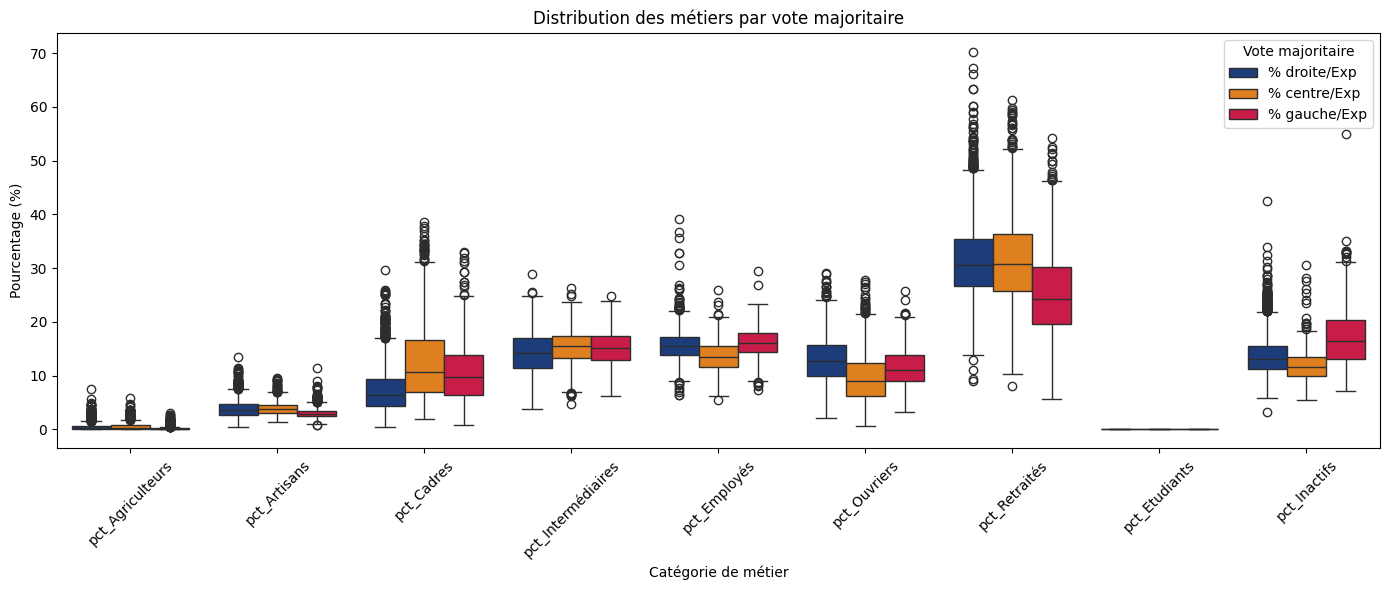

In [610]:
# Transformer le dataframe en format long pour seaborn
df_metier = df[metier + ['majorite']].melt(
    id_vars='majorite',
    value_vars=metier,
    var_name='metier',
    value_name='pourcentage'
)

# Boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_metier,
    x='metier',
    y='pourcentage',
    hue='majorite',
    palette={'% gauche/Exp': '#E4003A', '% centre/Exp': '#FF8000','% droite/Exp': '#0D378A'}
)

plt.title('Distribution des métiers par vote majoritaire')
plt.xlabel('Catégorie de métier')
plt.ylabel('Pourcentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Vote majoritaire')
plt.tight_layout()
plt.show()

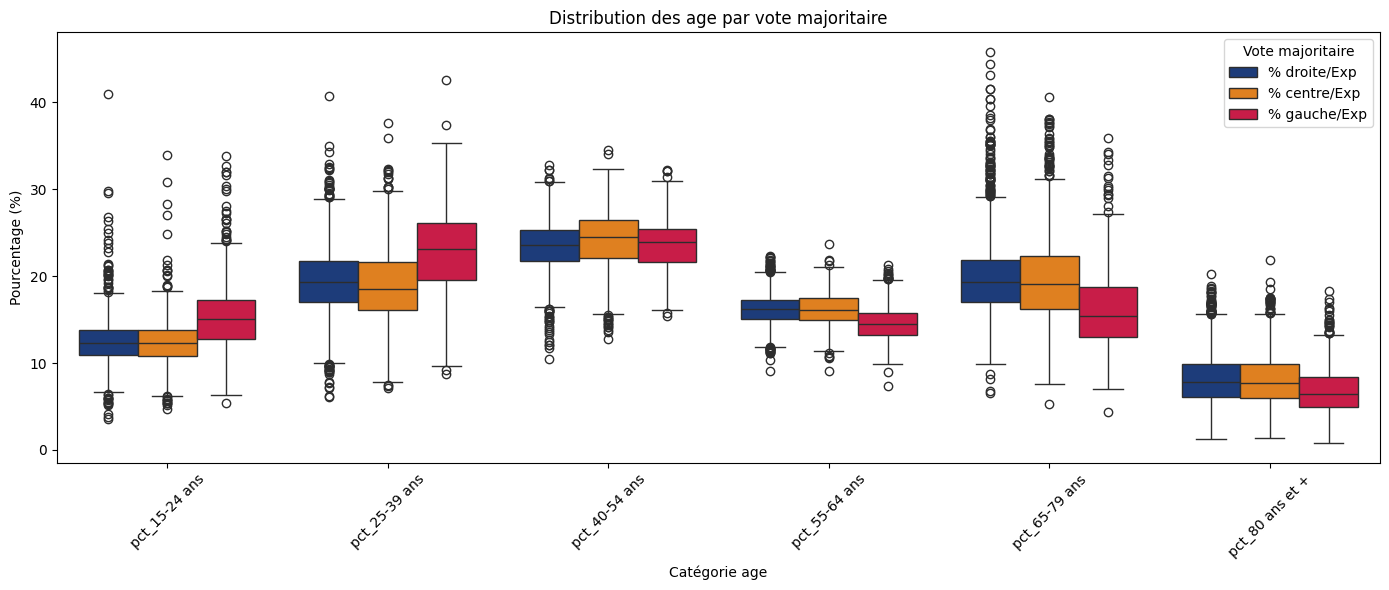

In [611]:
# Transformer le dataframe en format long pour seaborn
df_age = df[age + ['majorite']].melt(
    id_vars='majorite',
    value_vars=age,
    var_name='age',
    value_name='pourcentage'
)

# Boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_age,
    x='age',
    y='pourcentage',
    hue='majorite',
    palette={'% gauche/Exp': '#E4003A', '% centre/Exp': '#FF8000','% droite/Exp': '#0D378A'}
)

plt.title('Distribution des age par vote majoritaire')
plt.xlabel('Catégorie age')
plt.ylabel('Pourcentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Vote majoritaire')
plt.tight_layout()
plt.show()

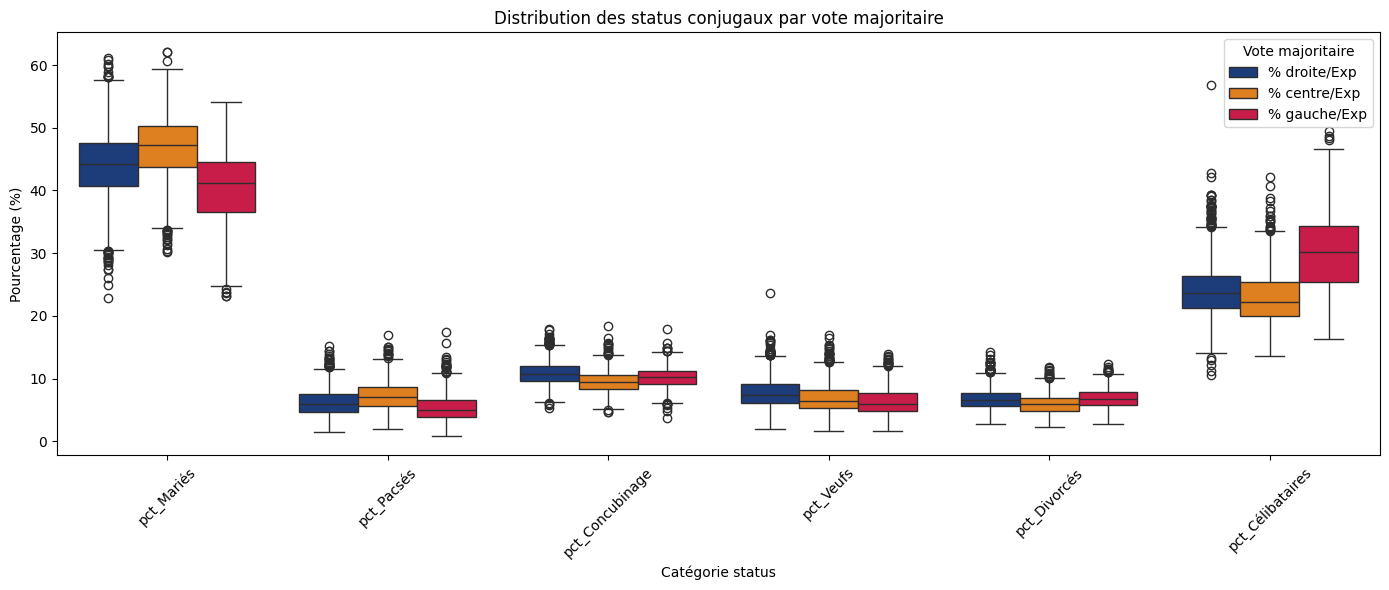

In [612]:
# Transformer le dataframe en format long pour seaborn
df_status = df[status + ['majorite']].melt(
    id_vars='majorite',
    value_vars=status,
    var_name='status',
    value_name='pourcentage'
)

# Boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_status,
    x='status',
    y='pourcentage',
    hue='majorite',
    palette={'% gauche/Exp': '#E4003A', '% centre/Exp': '#FF8000','% droite/Exp': '#0D378A'}
)

plt.title('Distribution des status conjugaux par vote majoritaire')
plt.xlabel('Catégorie status')
plt.ylabel('Pourcentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Vote majoritaire')
plt.tight_layout()
plt.show()

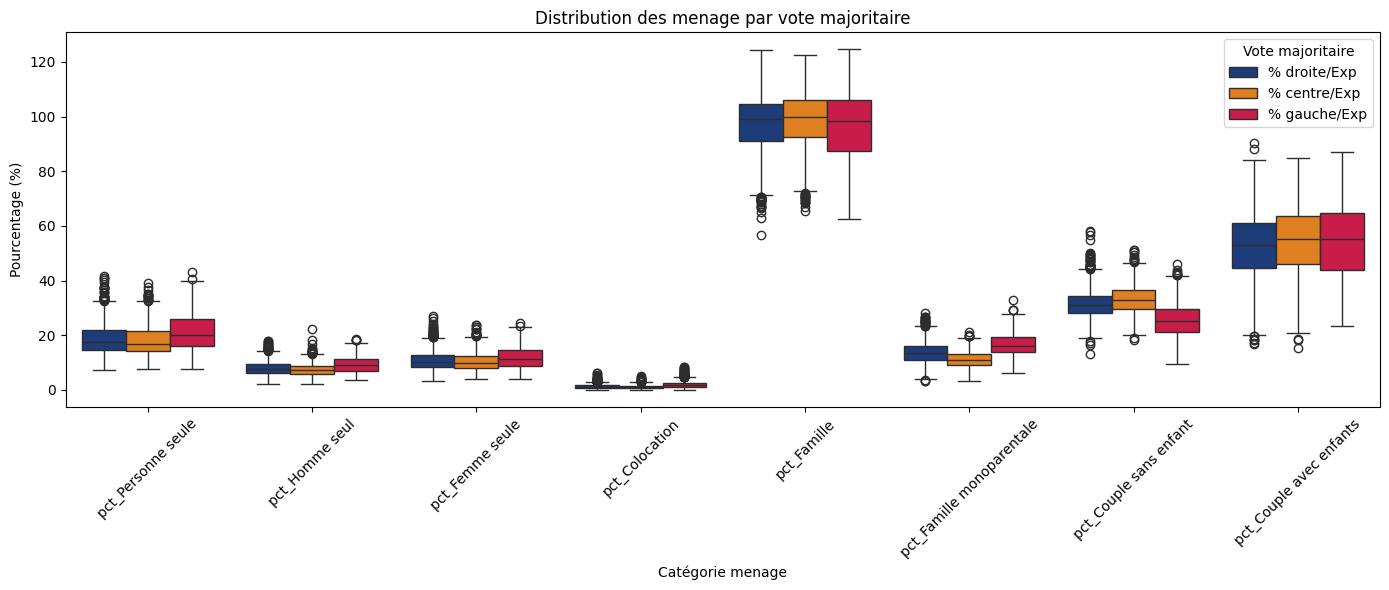

In [613]:
# Transformer le dataframe en format long pour seaborn
df_menage = df[menage + ['majorite']].melt(
    id_vars='majorite',
    value_vars=menage,
    var_name='menage',
    value_name='pourcentage'
)

# Boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_menage,
    x='menage',
    y='pourcentage',
    hue='majorite',
    palette={'% gauche/Exp': '#E4003A', '% centre/Exp': '#FF8000','% droite/Exp': '#0D378A'}
)

plt.title('Distribution des menage par vote majoritaire')
plt.xlabel('Catégorie menage')
plt.ylabel('Pourcentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Vote majoritaire')
plt.tight_layout()
plt.show()

### Corrélation 

In [614]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix[corr_matrix.abs() > 0.5].stack().dropna()

Inscrits        Inscrits           1.000000
                Abstentions        0.984780
                Votants            0.998508
                Blancs             0.984330
                Nuls               0.942582
                                     ...   
sum_menage_top  pct_40-54 ans      0.712103
                pct_65-79 ans     -0.610229
                pct_80 ans et +   -0.748135
                pct_Veufs         -0.675301
                sum_menage_top     1.000000
Length: 407, dtype: float64

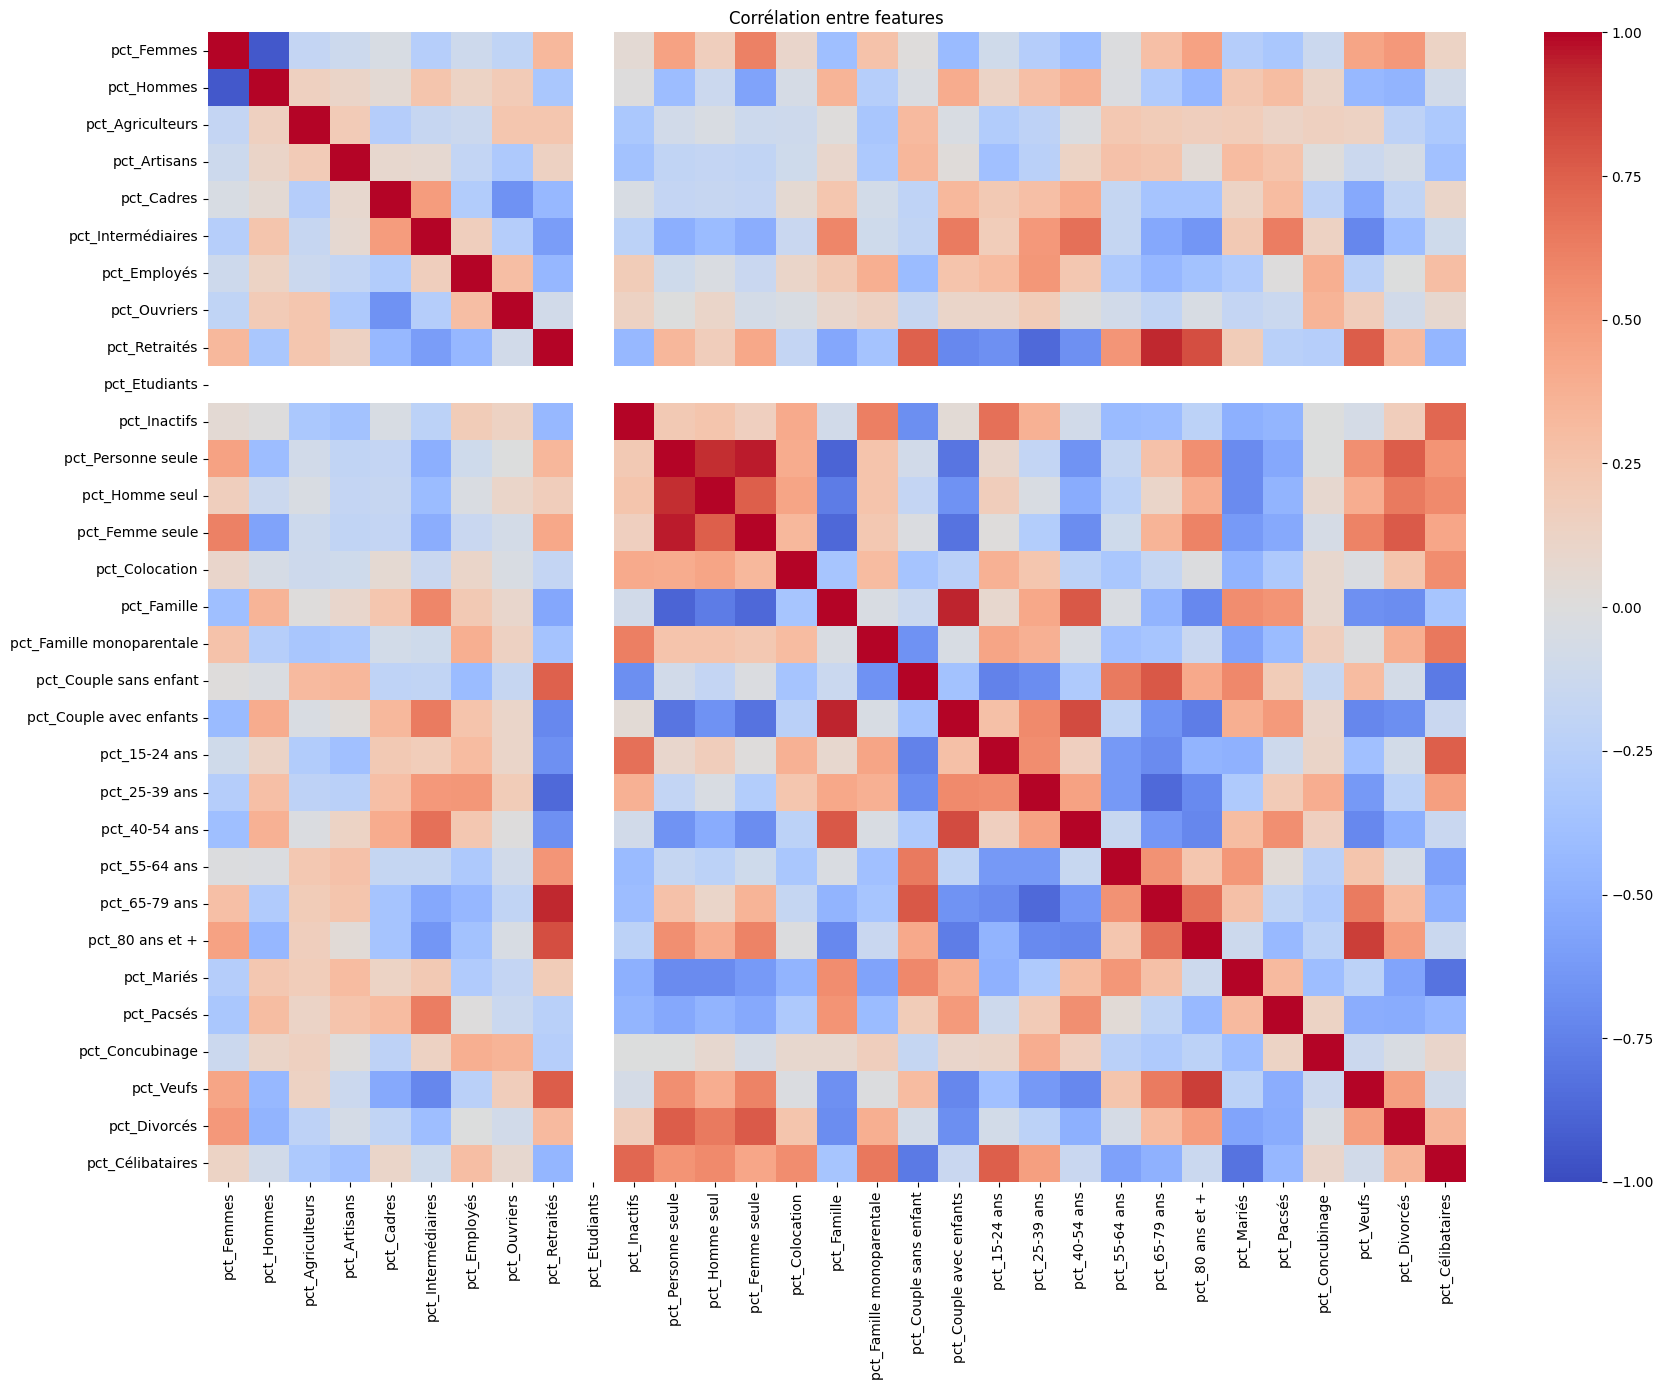

In [615]:
import seaborn as sns
import matplotlib.pyplot as plt

# Colonnes features uniquement (sans colonnes elections et cible)
features = ['pct_Femmes', 'pct_Hommes',
       'pct_Agriculteurs', 'pct_Artisans', 'pct_Cadres', 'pct_Intermédiaires',
       'pct_Employés', 'pct_Ouvriers', 'pct_Retraités', 'pct_Etudiants',
       'pct_Inactifs', 'pct_Personne seule', 'pct_Homme seul',
       'pct_Femme seule', 'pct_Colocation', 'pct_Famille',
       'pct_Famille monoparentale', 'pct_Couple sans enfant',
       'pct_Couple avec enfants',
       'pct_15-24 ans', 'pct_25-39 ans', 'pct_40-54 ans', 'pct_55-64 ans',
       'pct_65-79 ans', 'pct_80 ans et +', 'pct_Mariés', 'pct_Pacsés',
       'pct_Concubinage', 'pct_Veufs', 'pct_Divorcés', 'pct_Célibataires',
]

corr_matrix = df[features].corr()

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1
)

plt.title('Corrélation entre features')
plt.tight_layout()
plt.show()

In [616]:
# Paires de features avec corrélation > 0.8 ou < -0.8
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[
    ((corr_pairs > 0.7) | (corr_pairs < -0.7)) & (corr_pairs != 1.0)
].sort_values(ascending=False)

# Supprimer les doublons (A-B et B-A)
corr_pairs = corr_pairs[~corr_pairs.index.duplicated()]

print(corr_pairs)

pct_Femme seule          pct_Personne seule         0.956073
pct_Personne seule       pct_Femme seule            0.956073
pct_Famille              pct_Couple avec enfants    0.937510
pct_Couple avec enfants  pct_Famille                0.937510
pct_65-79 ans            pct_Retraités              0.933744
                                                      ...   
pct_Famille              pct_Femme seule           -0.873516
                         pct_Personne seule        -0.888240
pct_Personne seule       pct_Famille               -0.888240
pct_Femmes               pct_Hommes                -0.943061
pct_Hommes               pct_Femmes                -0.943061
Length: 70, dtype: float64


In [617]:
df[features].describe().loc[['mean', 'std', 'max']].T.sort_values('max')

,mean,std,max
pct_Etudiants,0.000000,0.000000,0.000000
pct_Agriculteurs,0.459633,0.662484,7.482991
pct_Colocation,1.400943,0.897026,8.338417
pct_Artisans,3.715943,1.463730,13.513336
pct_Divorcés,6.668848,1.635698,14.283984
pct_Pacsés,6.288272,2.265451,17.449970
pct_Concubinage,10.445733,1.844055,18.429142
pct_80 ans et +,8.031292,2.994556,21.890996
pct_Homme seul,8.099501,2.572716,22.464675
pct_Veufs,7.344053,2.345769,23.579913


In [618]:
def supprimer_redondantes(corr_matrix, seuil=0.7):
    a_supprimer = set()
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= seuil:
                # Garder la première, supprimer la deuxième
                a_supprimer.add(corr_matrix.columns[j])
    return list(a_supprimer)

cols_a_supprimer = supprimer_redondantes(corr_matrix, seuil=0.7)
print(f"Colonnes supprimées : {cols_a_supprimer}")
df = df.drop(columns=cols_a_supprimer)

Colonnes supprimées : ['pct_80 ans et +', 'pct_Célibataires', 'pct_Femme seule', 'pct_Hommes', 'pct_Homme seul', 'pct_Divorcés', 'pct_Couple avec enfants', 'pct_40-54 ans', 'pct_Famille', 'pct_15-24 ans', 'pct_Couple sans enfant', 'pct_25-39 ans', 'pct_65-79 ans', 'pct_Veufs']


In [619]:
colonnes_a_supprimer = [
    # Leak électoral
    '% gauche/Exp', '% centre/Exp', '% droite/Exp', 'Résultat',
    'Inscrits', 'Abstentions', '% Abs/Ins', 'Votants', '% Vot/Ins',
    'Blancs', '% Blancs/Ins', '% Blancs/Vot', 'Nuls', '% Nuls/Ins',
    '% Nuls/Vot', 'Exprimés', '% Exp/Ins', '% Exp/Vot',
    # Identifiants
    'Année', 'Code_INSEE', 'Libellé de la commune',
    #inutile
    'pct_Etudiants', 'sum_metier', 'sum_age', 'sum_status', 'sum_menage_top'
]

df = df.drop(columns=colonnes_a_supprimer)

print(f"Colonnes restantes : {df.shape[1]}")
print(df.columns.tolist())

Colonnes restantes : 19
['pct_Femmes', 'pct_Agriculteurs', 'pct_Artisans', 'pct_Cadres', 'pct_Intermédiaires', 'pct_Employés', 'pct_Ouvriers', 'pct_Retraités', 'pct_Inactifs', 'pct_Personne seule', 'pct_Colocation', 'pct_Famille monoparentale', 'pct_Population avec enfants', 'pct_55-64 ans', 'pct_Mariés', 'pct_Pacsés', 'pct_Concubinage', 'Population_active', 'majorite']


In [620]:
print(df['majorite'].value_counts())

majorite
% droite/Exp    2536
% centre/Exp     866
% gauche/Exp     681
Name: count, dtype: int64


In [621]:
def categorie_commune(habitants):
    if habitants < 2000:
        return "rurale"
    elif habitants < 10000:
        return "petite_commune"
    elif habitants < 50000:
        return "ville_moyenne"
    elif habitants < 100000:
        return "grande_ville"
    else:
        return "tres_grande_ville"

df['categorie_commune'] = df['Population_active'].apply(categorie_commune)

# Vérification
print(df['categorie_commune'].value_counts())

categorie_commune
petite_commune       3310
ville_moyenne         684
grande_ville           57
tres_grande_ville      32
Name: count, dtype: int64


In [622]:
df = pd.get_dummies(df, columns=['categorie_commune'], prefix='commune')

# Vérification
print(df.columns.tolist())

['pct_Femmes', 'pct_Agriculteurs', 'pct_Artisans', 'pct_Cadres', 'pct_Intermédiaires', 'pct_Employés', 'pct_Ouvriers', 'pct_Retraités', 'pct_Inactifs', 'pct_Personne seule', 'pct_Colocation', 'pct_Famille monoparentale', 'pct_Population avec enfants', 'pct_55-64 ans', 'pct_Mariés', 'pct_Pacsés', 'pct_Concubinage', 'Population_active', 'majorite', 'commune_grande_ville', 'commune_petite_commune', 'commune_tres_grande_ville', 'commune_ville_moyenne']


              precision    recall  f1-score   support

% centre/Exp       0.42      0.86      0.56       173
% droite/Exp       0.90      0.53      0.67       508
% gauche/Exp       0.54      0.65      0.59       136

    accuracy                           0.62       817
   macro avg       0.62      0.68      0.61       817
weighted avg       0.74      0.62      0.63       817



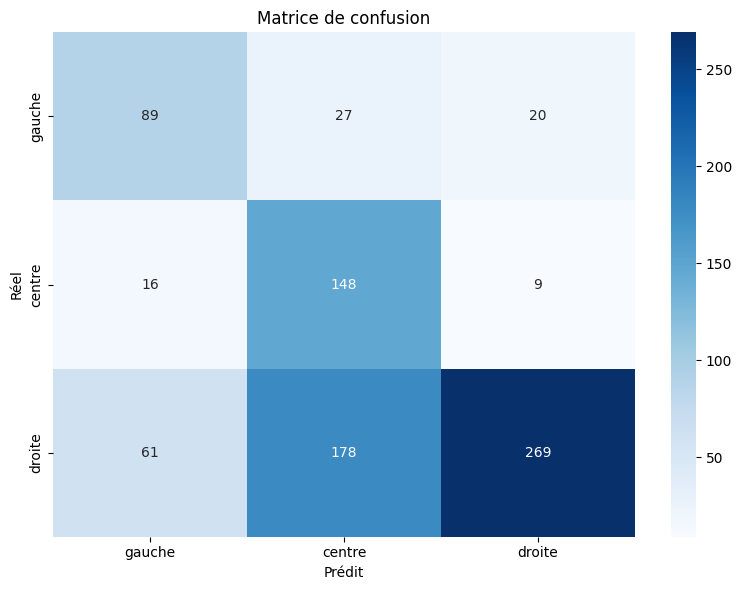

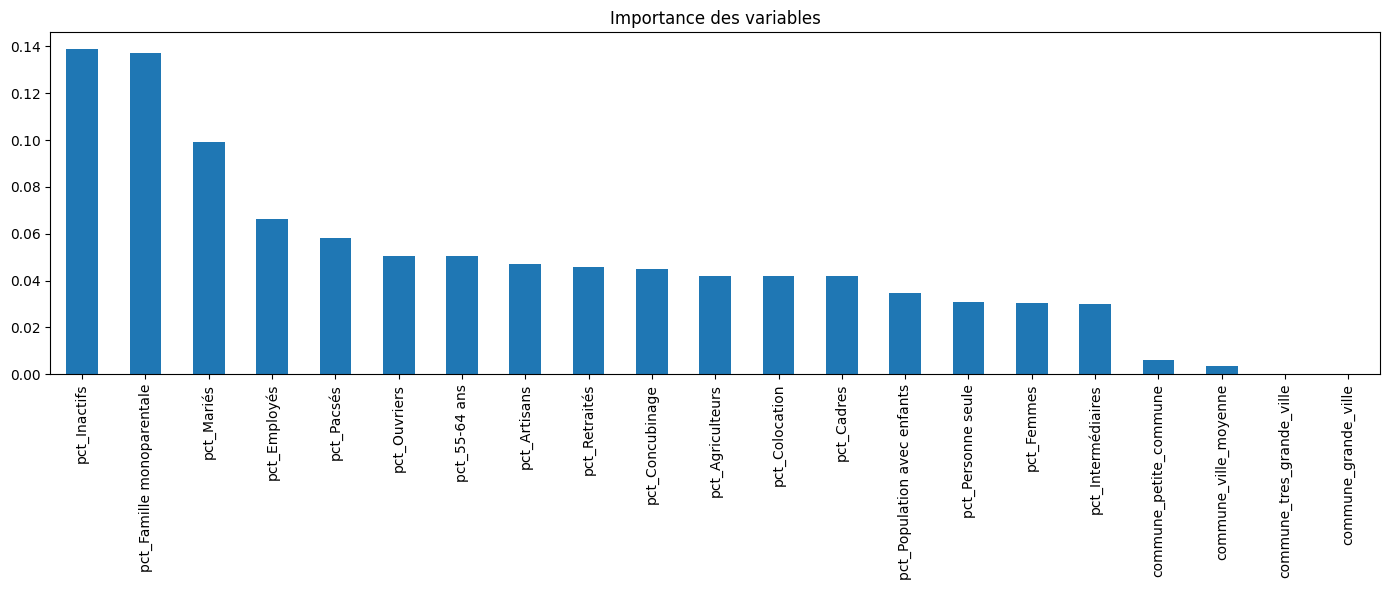


Features peu utiles (importance < 1%) :
commune_petite_commune       0.005837
commune_ville_moyenne        0.003612
commune_tres_grande_ville    0.000219
commune_grande_ville         0.000028
dtype: float64


In [623]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Features et cible
features = [col for col in df.columns if col not in [
    'Résultat', 'Année', 'Libellé de la commune', 'Code_INSEE',
    'Population_active', 'majorite',
    '% gauche/Exp', '% centre/Exp', '% droite/Exp',
    'Inscrits', 'Abstentions', '% Abs/Ins', 'Votants', '% Vot/Ins',
    'Blancs', '% Blancs/Ins', '% Blancs/Vot', 'Nuls', '% Nuls/Ins',
    '% Nuls/Vot', 'Exprimés', '% Exp/Ins', '% Exp/Vot',
    'pct_Etudiants', 'pct_Hommes', 'pct_Homme seul', 'pct_Femme seule', 'pct_Famille'
]]

X = df[features]
y = df['majorite']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Modèle
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    class_weight={
        '% droite/Exp': 1,
        '% centre/Exp': 30,
        '% gauche/Exp': 30
    },
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Evaluation
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred, labels=['% gauche/Exp', '% centre/Exp', '% droite/Exp'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['gauche', 'centre', 'droite'],
            yticklabels=['gauche', 'centre', 'droite'],
            cmap='Blues')
plt.title('Matrice de confusion')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

# Importance des variables
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(14, 6))
importances.plot(kind='bar')
plt.title('Importance des variables')
plt.tight_layout()
plt.show()

# Features proches de 0
print("\nFeatures peu utiles (importance < 1%) :")
print(importances[importances < 0.01])

Distribution après SMOTE :
majorite
% droite/Exp    2028
% gauche/Exp    2028
% centre/Exp    2028
Name: count, dtype: int64
              precision    recall  f1-score   support

% centre/Exp       0.54      0.71      0.61       173
% droite/Exp       0.82      0.78      0.80       508
% gauche/Exp       0.70      0.55      0.62       136

    accuracy                           0.73       817
   macro avg       0.69      0.68      0.68       817
weighted avg       0.74      0.73      0.73       817



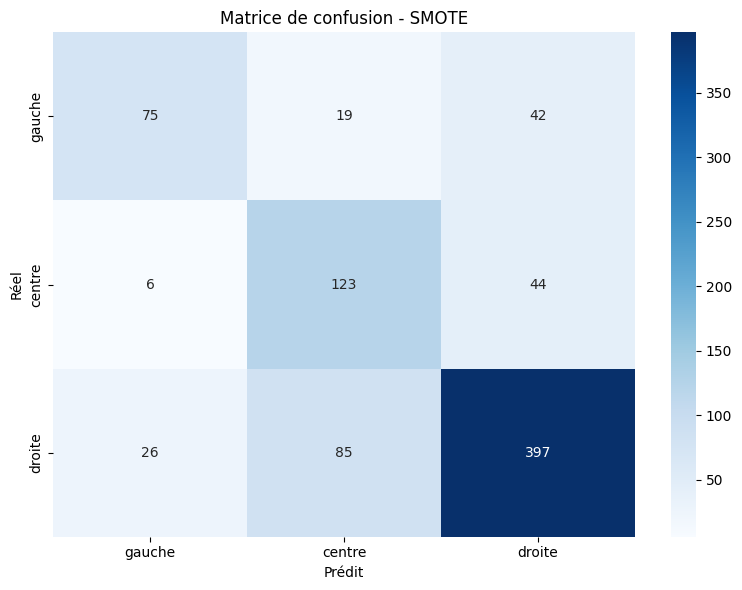

In [624]:
from imblearn.over_sampling import SMOTE

# SMOTE uniquement sur le train set
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Vérification de l'équilibre après SMOTE
print("Distribution après SMOTE :")
print(pd.Series(y_train_smote).value_counts())

# Modèle sans class_weight car SMOTE équilibre déjà
rf_smote = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)

# Evaluation
y_pred_smote = rf_smote.predict(X_test)
print(classification_report(y_test, y_pred_smote))

# Matrice de confusion
cm_smote = confusion_matrix(y_test, y_pred_smote, labels=['% gauche/Exp', '% centre/Exp', '% droite/Exp'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm_smote, annot=True, fmt='d',
            xticklabels=['gauche', 'centre', 'droite'],
            yticklabels=['gauche', 'centre', 'droite'],
            cmap='Blues')
plt.title('Matrice de confusion - SMOTE')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()